## Utils

In [1]:
from typing import List, Dict, Tuple, Callable
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)


In [3]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

# Ordinary Least Squares

## Data Loading

In [4]:
df = pd.read_csv("calories.csv")

In [5]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [7]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [8]:
data_isNull = df.isnull()
display(data_isNull)
hasnull = np.any(data_isNull)

print(f"Value of hasnull is {hasnull}")

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False


Value of hasnull is False


## Visualization


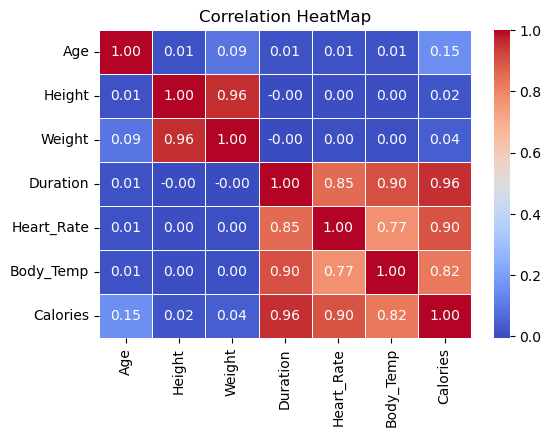

In [9]:
corr_matrix = df.drop(columns=['User_ID']).corr(numeric_only=True)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation HeatMap")
plt.show()

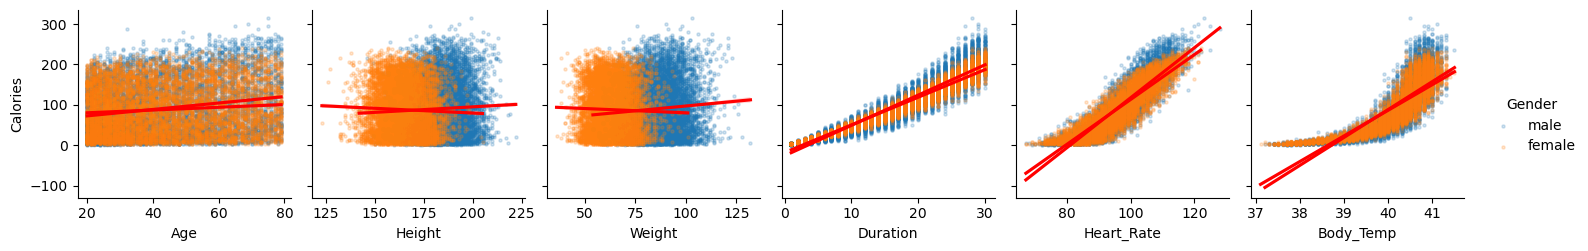

In [10]:
## Drop uneccesary columns and target column
feature_data = df.drop(columns=['User_ID', 'Calories'])
target_data = df['Calories']
sns.pairplot(df, hue='Gender', x_vars=feature_data.drop(columns=['Gender']).columns, y_vars='Calories', kind='reg', plot_kws={'scatter_kws': {'alpha': 0.2, 's': 5}, 'line_kws': {'color': 'red'}})

plt.show()

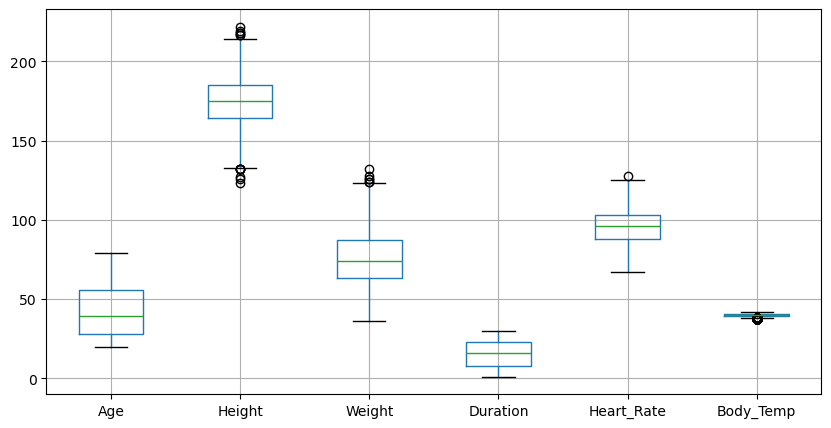

In [11]:
dropped_gender_df = feature_data.drop(columns=['Gender'])
dropped_gender_df.boxplot(figsize=(10, 5))
plt.show()

## Data Preprocessing

### Data Splitting

In [12]:
def get_train_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
):
    """ Randomizes and then splits the data into train and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    assert isinstance(X, np.ndarray), f'`X` must be a NumPy array, got type {type(X)} instead.'
    assert isinstance(y, np.ndarray), f'`y` must be a NumPy array, got type {type(y)} instead.'
    
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
    
    return X_trn, y_trn, X_tst, y_tst

In [13]:
def add_bias(X: np.ndarray) -> np.ndarray:
    # TODO 6.1
    """ Add bias term to input features.

        Args:
            X: Input feature data given as a matrix.

        Return: 
            Matrix where first column contains the bias term
    """
    bias = None
    bias = np.ones((len(X), 1))
    combined = np.hstack((bias, X))
    
    return combined

### Preprocess Data


In [14]:
def get_preprocessed_data() -> Tuple[np.ndarray]:
    """ Gets preprocessed data for training and testing

        Return:
            A tuple of NumPy arrays where the first two indices 
            contain the training data and targets and the last two
            indicies contain the testing data and targets.
    """
    
    X = df.drop(columns=['User_ID', 'Calories'])
    X['Gender'] = X['Gender'].map({'male': 1, 'female': 0})
    y = df['Calories']

    X_trn, y_trn, X_tst, y_tst = get_train_test_data(X.to_numpy(), y.to_numpy())
    
    standard_scaler = StandardScaler()
    standard_scaler.fit(X_trn)
    X_trn = standard_scaler.transform(X_trn)
    X_tst = standard_scaler.transform(X_tst)
    
    X_trn = add_bias(X_trn)
    X_tst = add_bias(X_tst)
    
    
    return X_trn, y_trn, X_tst, y_tst

## Coding Ordinary Least Squares 

In [15]:
class OrdinaryLeastSquares():
    """ Perfroms ordinary least squares regression
    
        Attributes:
            w: The weights learned by using the normal equation

    """
    def __init__(self):
        self.w  = None
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> object:
        """ Train OLS to learn optimal weights

            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 1D vector
                
            Return:
                The class's own object reference. 
        """
        # TODO 9.1
        ### BEGIN SOLUTION
        self.w = np.linalg.pinv((X.T @ X)) @ X.T @ y
        ### END SOLUTION
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Testing data given as a 2D matrix

            Return:
                Returns a 1D vector of predictions for each data sample in X
        """
        # TODO 9.2
        ### BEGIN SOLUTION
        y_hat = X @ self.w
        return y_hat
        ### END SOLUTION
        

### Testing

In [16]:
X_trn, y_trn, X_tst, y_tst = get_preprocessed_data()

ols = OrdinaryLeastSquares()

ols.fit(X_trn, y_trn)

y_trn_hat = ols.predict(X_trn)
y_tst_hat = ols.predict(X_tst)

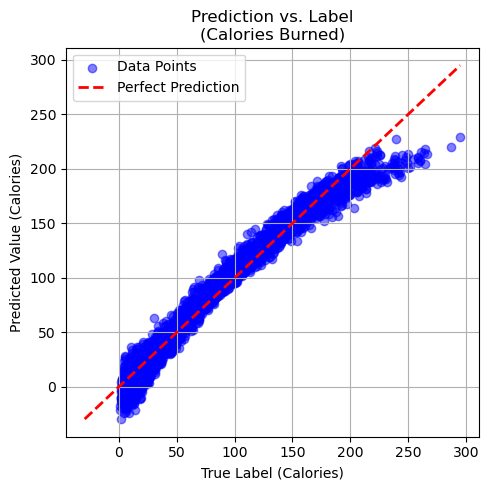

In [17]:
plt.figure(figsize=(5, 5))

target_name = 'Calories'

plt.scatter(y_tst, y_tst_hat, color='blue', alpha=0.5, label='Data Points')

min_val = min(y_tst.min().item(), y_tst_hat.min())
max_val = max(y_tst.max().item(), y_tst_hat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel(f"True Label ({target_name})")
plt.ylabel(f"Predicted Value ({target_name})")
plt.title(f"Prediction vs. Label\n(Calories Burned)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
trn_mse_score = mse(y_trn, y_trn_hat)
trn_rmse_score = rmse(y_trn, y_trn_hat)

print(f"Training MSE: {trn_mse_score}")
print(f"Training RMSE: {trn_rmse_score}")

Training MSE: 126.94582456688235
Training RMSE: 11.267023767032816


In [19]:
tst_mse_score = mse(y_tst, y_tst_hat)
tst_rmse_score = rmse(y_tst, y_tst_hat)

print(f"Testing MSE: {tst_mse_score}")
print(f"Testing RMSE: {tst_rmse_score}")

Testing MSE: 131.99574575081684
Testing RMSE: 11.488940149152873


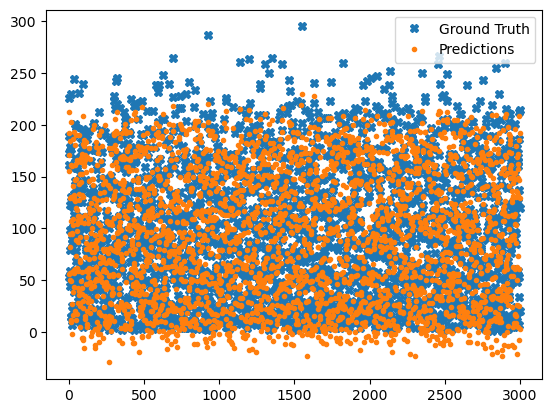

In [20]:
plt.plot(y_tst, 'X', label='Ground Truth')
plt.plot(ols.predict(X_tst), '.', label='Predictions')
plt.legend()
plt.show()

# Neural Network

## Data Preprocessing

In [21]:
def get_train_valid_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [22]:
def get_neural_network_preprocessed_data() -> Tuple[np.ndarray, ...]:
    """ Gets preprocessed data for training, validation, and testing

        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """
    X = df.drop(columns=['User_ID', 'Calories'])
    X['Gender'] = X['Gender'].map({'male': 1, 'female': 0})
    y = df['Calories']
    
    # Split dataset
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X.to_numpy(), y.to_numpy())

    # Standardize features
    scaler = StandardScaler()
    X_trn = scaler.fit_transform(X_trn)
    X_vld = scaler.transform(X_vld)
    X_tst = scaler.transform(X_tst)


    return X_trn, y_trn.reshape(-1, 1), X_vld, y_vld.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

## Activation Functions

In [23]:
class Linear():
    """ The linear or identity actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the linear activation function """
        # TODO 1.1
        # YOUR CODE HERE
        return z
        pass
    
    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative for the linear activation function """
        # TODO 1.2
        # YOUR CODE HERE
        return np.ones(z.shape)

In [24]:
class Tanh():
    """ The tanh actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the tanh activation function """
        # TODO 2.1
        # YOUR CODE HERE
        return np.tanh(z)

    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative of the tanh activation function """
        # TODO 2.2
        # YOUR CODE HERE
        return 1 - np.tanh(z)**2

## Initialize Weights

In [25]:
def init_weights(
    m_input_features: int, 
    hidden_neurons: int, 
    output_neurons: int, 
) -> Tuple[np.ndarray, ...]:
    """ Initilize the hidden and output layer parameters
        
        Args:
            m_input_features: The number of input features

            hidden_neurons: The number of hidden neurons or units to 
                use in the hidden layer.

            output_neurons: The number of output neurons to use in 
                the output layer.

        Returns:
            A tuple of NumPy arrays containing the weights and biases
            for the hidden and output layers.
    """
    
    W1, b1, W2, b2 = None, None, None, None
    # YOUR CODE HERE
    W1 = np.random.uniform(low=-0.5, high=0.5, size=(m_input_features, hidden_neurons))
    b1 = np.ones([1, hidden_neurons])
    W2 = np.random.uniform(low=-0.5, high=0.5, size=(hidden_neurons, output_neurons))
    b2 = np.ones([1, output_neurons])
    
    return W1, b1, W2, b2

## Forward Pass

In [26]:
def forward(
    X: np.ndarray, 
    W1: np.ndarray, 
    b1: np.ndarray,
    W2: np.ndarray, 
    b2: np.ndarray, 
) -> Tuple[np.ndarray, ...]:
    """ Forward pass for 2 layer neural network
    
        Args:
            X: Input features
            
            W1: Hidden layer weights 
            
            b1: Hidden layer baises

            W2: Output layer weights 
            
            b2: Output layer baises

        Returns:
            A tuple of NumPy arrays containing the linear combination and 
            acitvation outputs for each layer. These are needed to compute 
            the backward pass.
    """
    Z1, A1, Z2, A2 = None, None, None, None
    
    Z1 = X @ W1 + b1
    A1 = Tanh.activation(Z1)
    Z2 = A1 @ W2 + b2
    A2 = Linear.activation(Z2)
    return Z1, A1, Z2, A2

## Backward Pass

In [27]:
def output_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the output layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the output layer weights and biases.
    """
    # TODO 5
    W2_avg_grad, b2_avg_grad = None, None
    # YOUR CODE HERE
    W2_avg_grad = (A1.T @ ((A2 - y) * Linear.derivative(Z2))) / len(y)
    b2_avg_grad = (np.ones(A2.shape).T @ ((A2 - y) * Linear.derivative(Z2))) / len(y)
    return W2_avg_grad, b2_avg_grad

### Hidden Layer

In [28]:
def hidden_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the hidden layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the hidden layer weights and biases.
    """
    
    W1_avg_grad, b1_avg_grad = None, None
    # YOUR CODE HERE
    W1_avg_grad = (X.T @ ((((A2 - y) * Linear.derivative(Z2)) @ W2.T) * Tanh.derivative(Z1))) / len(y)
    b1_avg_grad = (np.ones(A2.shape).T @ ((((A2 - y) * Linear.derivative(Z2)) @ W2.T) * Tanh.derivative(Z1))) / len(y)
    return W1_avg_grad, b1_avg_grad

## Coding a Neural Network

In [29]:
def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [30]:
class NeuralNetwork():
    def __init__(self,
        hidden_neurons: int,
        output_neurons: int,
        alpha: float, 
        batch_size: int,
        epochs: int = 1,
        seed: int = 0,
    ):
        """ A two layer neural network using SGD
            
            Attributes:
                hidden_neurons: Number of hidden units/neurons.
                
                output_neurons: Number of output neuorns
                
                alpha: learning rate or step size.
                
                batch_size: Size of mini-batches for mini-batch gradient
                    descent.
                
                epochs: Number of epochs to run for mini-batch
                    gradient descent.
                    
                seed: Seed to be used for NumPy's np.random.seed() function.
    
                W1: Hidden layer weights with shape (inputs, neurons)
                
                b1: Hidden layer baises with shape (1, neurons)
                
                W2: Output layer weights with shape (inputs, neurons)
                
                b2: Output layer baises with shape (1, neurons)
    
                trn_error: Stores the training error for each epoch.
    
                vld_error: Stores the validation error for each epoch.
        """
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.batch_size = batch_size
        self.alpha = alpha
        self.epochs = epochs
        self.seed = seed
        
        self.W1, self.b1 = None, None
        self.W2, self.b2 = None, None
        self.trn_error = None
        self.vld_error = None

    def fit(
        self,
        X: np.ndarray, 
        y: np.ndarray,
        X_vld: np.ndarray = None, 
        y_vld:np.ndarray = None,
    ): 
        """ Trains a basic two layer neural network using SGD
        
            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

                X_vld: Validation data given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.

                y_vld: Validation labels given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.
                
            Returns:
                The class's own object reference. 
        """
        np.random.seed(self.seed)
        self.trn_error = []
        self.vld_error = []
        
        self.W1, self.b1, self.W2, self.b2 = init_weights(X.shape[1], self.hidden_neurons, self.output_neurons)
        for e in range(self.epochs):
            batches = []
            batches = get_batches(len(X), self.batch_size)
            
            # Loop over batched data indices
            for b in batches:
                Z1, A1, Z2, A2 = forward(X[b], self.W1, self.b1, self.W2, self.b2)
                delta_mse_W2, delta_mse_B2 = output_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)
                delta_mse_W1, delta_mse_B1 = hidden_layer_grads(X[b], y[b], self.W1, Z1, A1, self.W2, Z2, A2)

                self.W2 = self.W2 - (self.alpha * delta_mse_W2)
                self.b2 = self.b2 - (self.alpha * delta_mse_B2)
                self.W1 = self.W1 - (self.alpha * delta_mse_W1)
                self.b1 = self.b1 - (self.alpha * delta_mse_B1)

            trn_preds = self.predict(X)
            trn_error = rmse(y, trn_preds)
            self.trn_error.append(trn_error)
            
            if X_vld is not None and y_vld is not None:
                vld_preds = self.predict(X_vld)
                vld_error = rmse(y_vld, vld_preds)
                self.vld_error.append(vld_error)
                    
        return self
    
    def predict(self, X: np.ndarray):
        """ Make predictions using forward pass.

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 7.3
        # YOUR CODE HERE
        Z1, A1, Z2, A2 = forward(X, self.W1, self.b1, self.W2, self.b2)
        return A2

## Calories Burned Prediction Training

Train RMSE: 1.5853048146516886
Validation RMSE: 1.6353515802439542
Testing RMSE: 1.6022686711437297


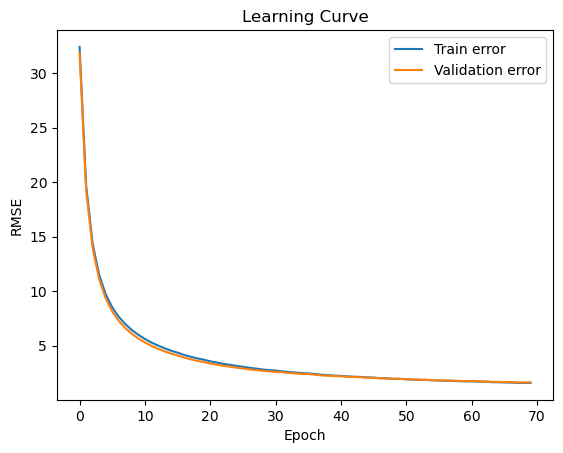

In [31]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_neural_network_preprocessed_data()

nn = NeuralNetwork(hidden_neurons=35, output_neurons=1, batch_size=250, alpha=0.003, epochs=70, seed=0)
nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
y_hat_trn = nn.predict(X_trn)
trn_rmse_score = rmse(y_trn, y_hat_trn)
print(f"Train RMSE: {trn_rmse_score}")

y_hat_vld = nn.predict(X_vld)
vld_rmse_score = rmse(y_vld, y_hat_vld)
print(f"Validation RMSE: {vld_rmse_score}")

y_hat_tst = nn.predict(X_tst)
tst_rmse_score = rmse(y_tst, y_hat_tst)
print(f"Testing RMSE: {tst_rmse_score}")

plt.plot(nn.trn_error, label='Train error')
plt.plot(nn.vld_error, label='Validation error')
plt.title("Learning Curve")
plt.ylabel("RMSE")
plt.xlabel("Epoch")
plt.legend()
plt.show()


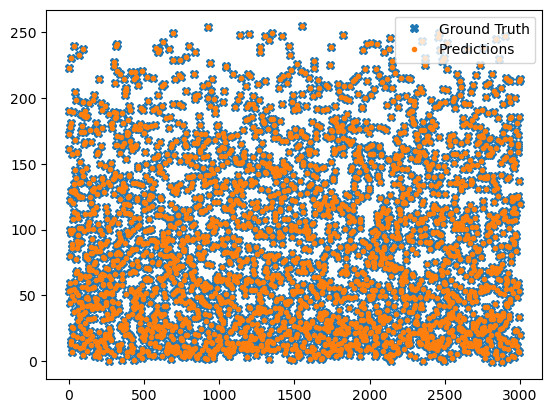

In [32]:
plt.plot(y_hat_tst, 'X', label='Ground Truth')
plt.plot(nn.predict(X_tst), '.', label='Predictions')
plt.legend()
plt.show()